<a href="https://colab.research.google.com/github/regitaaft/iris-eda-ml/blob/main/PROYEK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Kurs    303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB
None
Jumlah baris dan kolom: (303, 1)
Kurs    int64
dtype: object
Jumlah missing value:
Kurs    0
dtype: int64
Jumlah data duplikat: 13


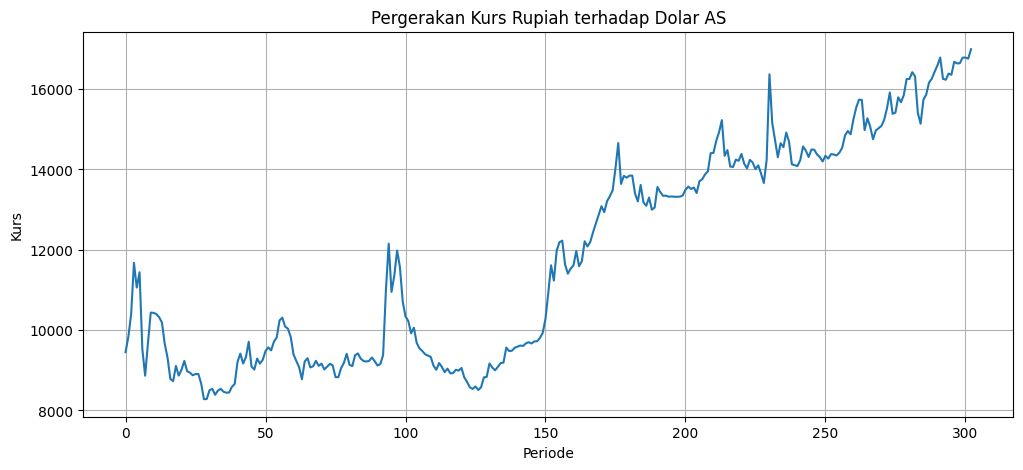

[[ 9450]
 [ 9835]
 [10400]
 [11675]
 [11058]]
(291, 12)
(291,)
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0494
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0098
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040
Epoch 9/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0040
Epoch 10/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0039
Epoch 11/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0038
Epoch 12/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0039
Epoch 13/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0037
Epoch 14/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0038
Epoch 15/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0039
E

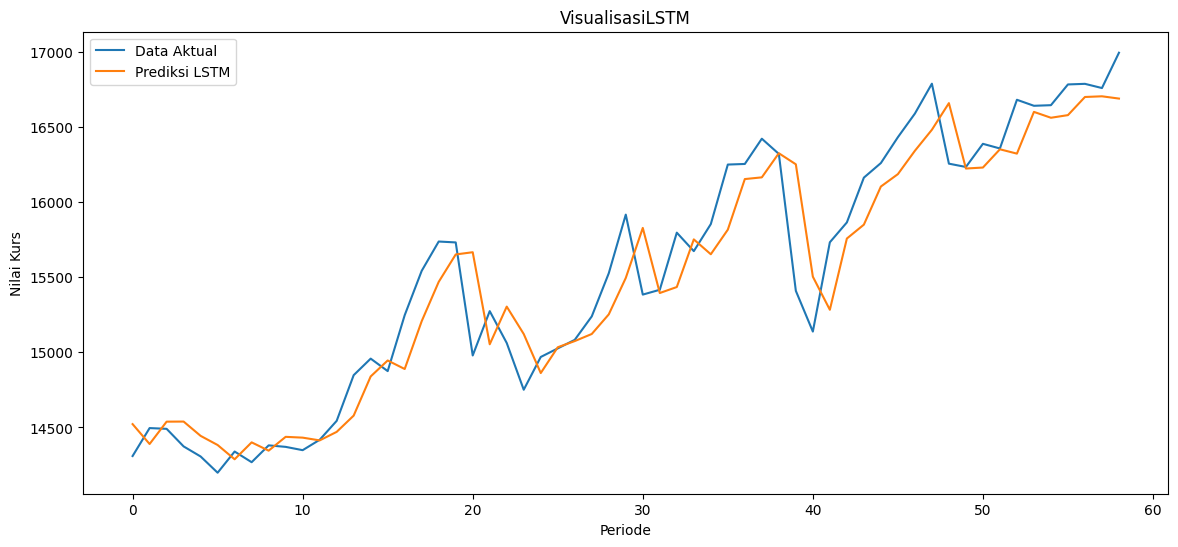

In [18]:
#IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

#UPLOAD DATA
data = pd.read_csv('fix.csv')

#EDA
data.head() #melihat 5 data pertama
print(data.info()) #INFORMASI STRUKTUR DATA
print("Jumlah baris dan kolom:", data.shape) #ukuran dataset
print(data.dtypes) #tipe data
data.describe() #data deskriptif
print("Jumlah missing value:")
print(data.isnull().sum()) #cek missing value
print("Jumlah data duplikat:", data.duplicated().sum()) #cek data duplikast

#visualisasi
plt.figure(figsize=(12,5))
plt.plot(data["Kurs"])
plt.title("Pergerakan Kurs Rupiah terhadap Dolar AS")
plt.xlabel("Periode")
plt.ylabel("Kurs")
plt.grid(True)
plt.show()

#AMBIL DATA KURS
dataset = data.iloc[:,0].values
dataset = dataset.reshape(-1,1)

print(dataset[:5])

#NORMALISASI
scaler = MinMaxScaler(feature_range=(0,1))
dataset_scaled = scaler.fit_transform(dataset)

#MEMBUAT DATA TIME SERIES
def create_dataset(data, time_step=3):

    X = []
    y = []

    for i in range(len(data)-time_step):

        X.append(data[i:(i+time_step),0])
        y.append(data[i+time_step,0])

    return np.array(X), np.array(y)

time_step = 12

X, y = create_dataset(dataset_scaled, time_step)

print(X.shape)
print(y.shape)

#SPLIT TRAINING TESTING
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

#MODEL LSTM

#RESHAPE MENJADI 3 DIMENSI
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

#MEMBUAT MODEL
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        50,
        return_sequences=False,
        input_shape=(time_step,1)
    )
)

lstm_model.add(Dense(1))

#COMPILE MODEL
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# TRAINING
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=150,
    batch_size=16,
    verbose=1
)

#PREDIKSI
lstm_pred = lstm_model.predict(X_test_lstm)

#KEMBALIKAN KE DATA ASLI
y_test_asli = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

lstm_pred_asli = scaler.inverse_transform(
    lstm_pred
)

#FUNGSI EVALUASI
def evaluasi(y_true, y_pred, nama_model):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    # Tambahan metrik R-squared (R2 Score)
    r2 = r2_score(y_true, y_pred)

    print(f"\n===== {nama_model} =====")
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("MAPE :", mape)
    print("R2   :", r2) # Menampilkan nilai R2
#HASIL LSTM
evaluasi(
    y_test_asli,
    lstm_pred_asli,
    "LSTM"
)

#VISUALISASI
plt.figure(figsize=(14,6))

plt.plot(
    y_test_asli,
    label='Data Aktual'
)

plt.plot(
    lstm_pred_asli,
    label='Prediksi LSTM'
)

plt.title('VisualisasiLSTM')

plt.xlabel('Periode')
plt.ylabel('Nilai Kurs')

plt.legend()

plt.show()

In [19]:
hasil = pd.DataFrame({
    'Aktual': y_test_asli.flatten(),
    'Prediksi_LSTM': lstm_pred_asli.flatten()
})

print(hasil.head(20))

     Aktual  Prediksi_LSTM
0   14310.0   14522.354492
1   14496.0   14390.017578
2   14491.0   14538.701172
3   14374.0   14539.313477
4   14307.0   14444.148438
5   14199.0   14383.351562
6   14340.0   14288.454102
7   14269.0   14400.994141
8   14381.0   14345.737305
9   14371.0   14437.684570
10  14349.0   14432.371094
11  14418.0   14414.068359
12  14544.0   14470.683594
13  14848.0   14578.938477
14  14958.0   14839.508789
15  14875.0   14945.660156
16  15247.0   14888.986328
17  15542.0   15207.157227
18  15737.0   15468.581055
19  15731.0   15651.042969
